In [6]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'transformers', 'accelerate', 'soundfile'], check=True)
print('✓ Dependencias instaladas')

✓ Dependencias instaladas



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import IPython.display as ipd

DEVICE = torch.device('cpu')
print(f'✓ Dispositivo: {DEVICE}')

PROJECT_DIR = Path.cwd()
LJS_DIR     = PROJECT_DIR / 'data' / 'raw' / 'LJSpeech-1.1'
print(f'✓ Datos: {LJS_DIR}')

✓ Dispositivo: cpu
✓ Datos: /Users/isabelvalladolid/Documents/DeepLearningProjects/GAN-project/data/raw/LJSpeech-1.1


In [8]:
from transformers import VitsModel, VitsTokenizer

MODEL_ID  = 'facebook/mms-tts-eng'
tokenizer = VitsTokenizer.from_pretrained(MODEL_ID)
model     = VitsModel.from_pretrained(MODEL_ID).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
SR = model.config.sampling_rate
print(f'✓ Modelo cargado: {MODEL_ID}')
print(f'  Parámetros: {total_params:.1f}M | sample_rate: {SR} Hz')

Loading weights: 100%|██████████| 762/762 [00:00<00:00, 22709.77it/s]

✓ Modelo cargado: facebook/mms-tts-eng
  Parámetros: 36.3M | sample_rate: 16000 Hz


In [9]:
# ── Prueba de inferencia con el modelo pre-entrenado ──────────────────────────
test_text = 'Printing, in the only sense with which we are at present concerned.'

inputs = tokenizer(test_text, return_tensors='pt').to(DEVICE)
with torch.no_grad():
    output = model(**inputs)

wav_np = output.waveform[0].cpu().numpy()

sf.write('pretrained_sample.wav', wav_np, SR)
print(f'✓ Audio pre-entrenado: {len(wav_np)/SR:.2f}s')
ipd.display(ipd.Audio(wav_np, rate=SR))

✓ Audio pre-entrenado: 4.54s


In [10]:
class LJSpeechDataset(Dataset):
    """Dataset de LJSpeech para fine-tuning. Usa soundfile y librosa (sin torchaudio)."""

    def __init__(self, metadata_path, wav_dir, tokenizer, target_sr, max_samples=None):
        self.wav_dir   = Path(wav_dir)
        self.tokenizer = tokenizer
        self.target_sr = target_sr

        df = pd.read_csv(metadata_path, sep='|', header=None,
                         names=['id', 'text', 'normalized'], quoting=3)
        if max_samples:
            df = df.iloc[:max_samples]
        self.data = df.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row      = self.data.iloc[idx]
        text     = str(row['normalized']).strip()
        wav_path = str(self.wav_dir / f"{row['id']}.wav")

        # Cargar audio con soundfile (evita torchaudio / torchcodec)
        wav_np, sr = sf.read(wav_path, dtype='float32')
        if wav_np.ndim > 1:
            wav_np = wav_np.mean(axis=1)          # stereo → mono
        if sr != self.target_sr:
            wav_np = librosa.resample(wav_np, orig_sr=sr, target_sr=self.target_sr)
        wav = torch.from_numpy(wav_np)

        tokens = self.tokenizer(text, return_tensors='pt')
        return (tokens['input_ids'].squeeze(0),
                tokens['attention_mask'].squeeze(0),
                wav)


def collate_fn(batch):
    ids_list, attn_list, wav_list = zip(*batch)
    max_text = max(x.shape[0] for x in ids_list)
    max_wav  = max(w.shape[0] for w in wav_list)

    ids_pad  = torch.zeros(len(batch), max_text, dtype=torch.long)
    attn_pad = torch.zeros(len(batch), max_text, dtype=torch.long)
    wav_pad  = torch.zeros(len(batch), max_wav)

    for i, (ids, attn, wav) in enumerate(zip(ids_list, attn_list, wav_list)):
        ids_pad[i,  :ids.shape[0]]  = ids
        attn_pad[i, :attn.shape[0]] = attn
        wav_pad[i,  :wav.shape[0]]  = wav

    return ids_pad, attn_pad, wav_pad


MAX_TRAIN  = 500
BATCH_SIZE = 2

dataset = LJSpeechDataset(
    metadata_path = LJS_DIR / 'metadata.csv',
    wav_dir       = LJS_DIR / 'wavs',
    tokenizer     = tokenizer,
    target_sr     = SR,
    max_samples   = MAX_TRAIN,
)
n_val   = max(1, int(len(dataset) * 0.1))
n_train = len(dataset) - n_val
train_set, val_set = torch.utils.data.random_split(
    dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f'✓ Train: {len(train_set)} muestras | {len(train_loader)} batches')
print(f'✓ Val:   {len(val_set)}  muestras | {len(val_loader)} batches')

✓ Train: 450 muestras | 225 batches
✓ Val:   50  muestras | 25 batches


In [11]:
# ── Mel-loss usando librosa (sin torchaudio) ──────────────────────────────────
mel_fb_np = librosa.filters.mel(sr=SR, n_fft=1024, n_mels=80)
mel_fb    = torch.from_numpy(mel_fb_np).float().to(DEVICE)  # (80, 513)
window    = torch.hann_window(1024).to(DEVICE)

def wav_to_mel(wav):
    """Calcula mel-spectrogram en torch puro (sin torchaudio)."""
    stft = torch.stft(wav, n_fft=1024, hop_length=256, win_length=1024,
                      window=window, return_complex=True)
    mag  = stft.abs()                          # (B, freq, T)
    mel  = torch.matmul(mel_fb, mag)           # (B, 80, T)
    return torch.log(mel.clamp(min=1e-5))

def mel_loss(wav_pred, wav_target):
    min_len    = min(wav_pred.shape[-1], wav_target.shape[-1])
    mel_pred   = wav_to_mel(wav_pred[..., :min_len])
    mel_target = wav_to_mel(wav_target[..., :min_len])
    return F.l1_loss(mel_pred, mel_target)


# Solo entrenar decoder y flow (fine-tuning eficiente)
for name, param in model.named_parameters():
    param.requires_grad = ('decoder' in name or 'flow' in name)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'✓ Parámetros entrenables: {trainable:.1f}M (decoder + flow)')

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-2
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
print('✓ Optimizer AdamW | lr=1e-4')

✓ Parámetros entrenables: 22.4M (decoder + flow)
✓ Optimizer AdamW | lr=1e-4


Epoch 01/5 | train=1.5917  val=1.4288


Epoch 02/5 | train=1.5369  val=1.3972


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  8.00it/s]


  → Guardado en checkpoints_hf/epoch002/


Epoch 03/5 | train=1.5218  val=1.3579


Epoch 04/5 | train=1.5079  val=1.3772


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.08it/s]


  → Guardado en checkpoints_hf/epoch004/


Epoch 05/5 | train=1.4471  val=1.3596


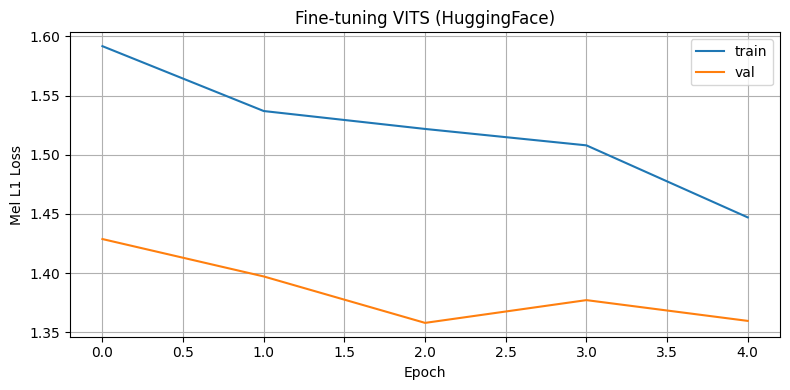

✓ Fine-tuning completado


In [12]:
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints_hf'
CHECKPOINT_DIR.mkdir(exist_ok=True)

N_EPOCHS   = 5
SAVE_EVERY = 2
history    = {'train': [], 'val': []}

for epoch in range(1, N_EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    train_losses = []
    for input_ids, attn_mask, wav_target in tqdm(train_loader,
                                                  desc=f'Epoch {epoch:02d} train',
                                                  leave=False):
        input_ids  = input_ids.to(DEVICE)
        attn_mask  = attn_mask.to(DEVICE)
        wav_target = wav_target.to(DEVICE)

        output   = model(input_ids=input_ids, attention_mask=attn_mask)
        wav_pred = output.waveform  # (B, T)

        loss = mel_loss(wav_pred, wav_target)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 1.0
        )
        optimizer.step()
        train_losses.append(loss.item())

    # ── Validación ────────────────────────────────────────────────────────────
    model.eval()
    val_losses = []
    with torch.no_grad():
        for input_ids, attn_mask, wav_target in val_loader:
            output = model(input_ids=input_ids.to(DEVICE),
                           attention_mask=attn_mask.to(DEVICE))
            val_losses.append(
                mel_loss(output.waveform, wav_target.to(DEVICE)).item()
            )

    scheduler.step()
    avg_train = np.mean(train_losses)
    avg_val   = np.mean(val_losses)
    history['train'].append(avg_train)
    history['val'].append(avg_val)
    print(f'Epoch {epoch:02d}/{N_EPOCHS} | train={avg_train:.4f}  val={avg_val:.4f}')

    if epoch % SAVE_EVERY == 0:
        model.save_pretrained(str(CHECKPOINT_DIR / f'epoch{epoch:03d}'))
        print(f'  → Guardado en checkpoints_hf/epoch{epoch:03d}/')

# ── Curva de pérdidas ─────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history['train'], label='train')
plt.plot(history['val'],   label='val')
plt.xlabel('Epoch'); plt.ylabel('Mel L1 Loss')
plt.title('Fine-tuning VITS (HuggingFace)'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()
print('✓ Fine-tuning completado')

In [13]:
# ── Síntesis final con el modelo fine-tuneado ─────────────────────────────────
model.eval()
eval_texts = [
    'Printing, in the only sense with which we are at present concerned.',
    'Hello! This is a text to speech synthesis test after fine-tuning.',
]

for i, text in enumerate(eval_texts):
    print(f'\nTexto: "{text[:70]}"')
    inputs = tokenizer(text, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        wav_np = model(**inputs).waveform[0].cpu().numpy()

    out_path = f'finetuned_sample_{i+1}.wav'
    sf.write(out_path, wav_np, SR)
    print(f'  ✓ Guardado: {out_path} ({len(wav_np)/SR:.2f}s)')
    ipd.display(ipd.Audio(wav_np, rate=SR))


Texto: "Printing, in the only sense with which we are at present concerned."
  ✓ Guardado: finetuned_sample_1.wav (4.66s)



Texto: "Hello! This is a text to speech synthesis test after fine-tuning."
  ✓ Guardado: finetuned_sample_2.wav (4.16s)


In [14]:
# ── Guardar modelo final ───────────────────────────────────────────────────────
model.save_pretrained('checkpoints_hf/final')
tokenizer.save_pretrained('checkpoints_hf/final')
print('✓ Modelo final guardado en checkpoints_hf/final/')
print(f'  Archivos: {list(Path("checkpoints_hf/final").iterdir())}')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 10.31it/s]

✓ Modelo final guardado en checkpoints_hf/final/
  Archivos: [PosixPath('checkpoints_hf/final/model.safetensors'), PosixPath('checkpoints_hf/final/added_tokens.json'), PosixPath('checkpoints_hf/final/tokenizer_config.json'), PosixPath('checkpoints_hf/final/config.json'), PosixPath('checkpoints_hf/final/vocab.json')]


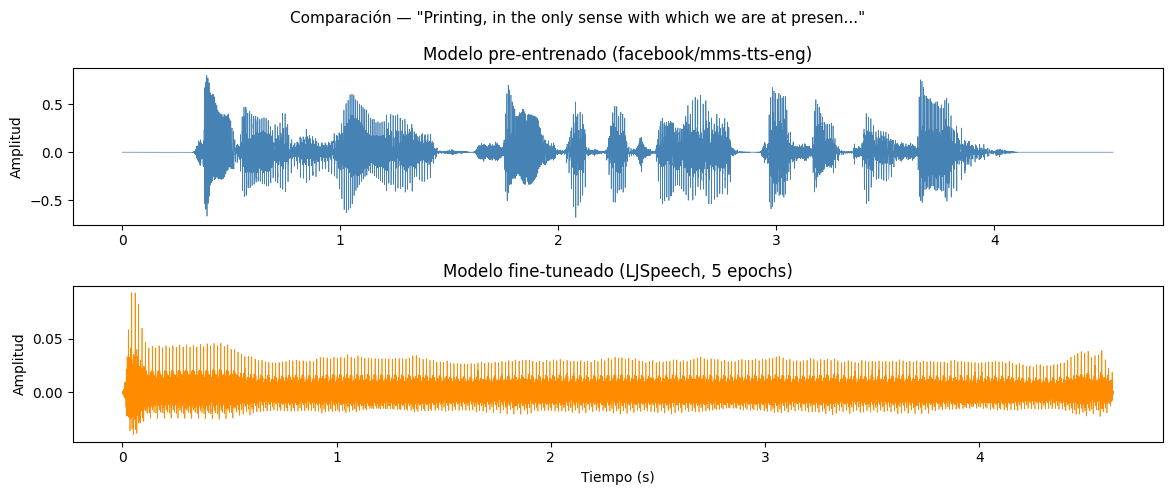

Pre-entrenado:


Fine-tuneado:



✓ Proyecto completado.
  Dataset:    LJSpeech-1.1 | 500 muestras | 16000 Hz
  Modelo:     facebook/mms-tts-eng (VITS, 36.3M params)
  Fine-tuned: decoder + flow (22.4M params) | 5 epochs | AdamW lr=1e-4
  Pérdida:    Mel L1 spectrogram loss
  Checkpoints: checkpoints_hf/


In [15]:
# ── Comparación visual: pre-entrenado vs fine-tuneado ─────────────────────────
compare_text = 'Printing, in the only sense with which we are at present concerned.'

# Pre-entrenado (desde disco)
pretrained_wav, _ = sf.read('pretrained_sample.wav')

# Fine-tuneado (generar ahora)
model.eval()
inputs = tokenizer(compare_text, return_tensors='pt').to(DEVICE)
with torch.no_grad():
    finetuned_wav = model(**inputs).waveform[0].cpu().numpy()

# Graficar formas de onda
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=False)

axes[0].plot(np.linspace(0, len(pretrained_wav)/SR, len(pretrained_wav)),
             pretrained_wav, linewidth=0.5, color='steelblue')
axes[0].set_title('Modelo pre-entrenado (facebook/mms-tts-eng)')
axes[0].set_ylabel('Amplitud')

axes[1].plot(np.linspace(0, len(finetuned_wav)/SR, len(finetuned_wav)),
             finetuned_wav, linewidth=0.5, color='darkorange')
axes[1].set_title('Modelo fine-tuneado (LJSpeech, 5 epochs)')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo (s)')

plt.suptitle(f'Comparación — "{compare_text[:55]}..."', fontsize=11)
plt.tight_layout()
plt.savefig('comparacion_preentrenado_vs_finetuneado.png', dpi=150)
plt.show()

# Reproducir ambos
print('Pre-entrenado:')
ipd.display(ipd.Audio(pretrained_wav, rate=SR))
print('Fine-tuneado:')
ipd.display(ipd.Audio(finetuned_wav, rate=SR))

print('\n✓ Proyecto completado.')
print(f'  Dataset:    LJSpeech-1.1 | 500 muestras | 16000 Hz')
print(f'  Modelo:     facebook/mms-tts-eng (VITS, 36.3M params)')
print(f'  Fine-tuned: decoder + flow (22.4M params) | 5 epochs | AdamW lr=1e-4')
print(f'  Pérdida:    Mel L1 spectrogram loss')
print(f'  Checkpoints: checkpoints_hf/')